Import Core Libraries

In [15]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [16]:
print("Environment ready")


Environment ready


Load ONE Subject (S10)

In [17]:
BASE_PATH = "WESAD"
SUBJECT = "S10"

subject_path = os.path.join(BASE_PATH, SUBJECT)
pkl_path = os.path.join(subject_path, f"{SUBJECT}.pkl")

with open(pkl_path, "rb") as f:
    data = pickle.load(f, encoding="latin1")

print(data.keys())


dict_keys(['signal', 'label', 'subject'])


Inspect Available Signals

In [18]:
print(data['signal'].keys())


dict_keys(['chest', 'wrist'])


Chest signals (RespiBAN)

In [19]:
print(data['signal']['chest'].keys())


dict_keys(['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp'])


Wrist signals (E4)

In [20]:
print(data['signal']['wrist'].keys())


dict_keys(['ACC', 'BVP', 'EDA', 'TEMP'])


Extract Raw Signals (Example)

In [21]:
ecg  = data['signal']['chest']['ECG']
eda  = data['signal']['chest']['EDA']
acc  = data['signal']['chest']['ACC']
labels = data['label']


In [22]:
print("ECG:", ecg.shape)
print("EDA:", eda.shape)
print("ACC:", acc.shape)
print("Labels:", labels.shape)


ECG: (3847200, 1)
EDA: (3847200, 1)
ACC: (3847200, 3)
Labels: (3847200,)


In [23]:
np.unique(labels)


array([0, 1, 2, 3, 4, 5, 6, 7], dtype=int32)

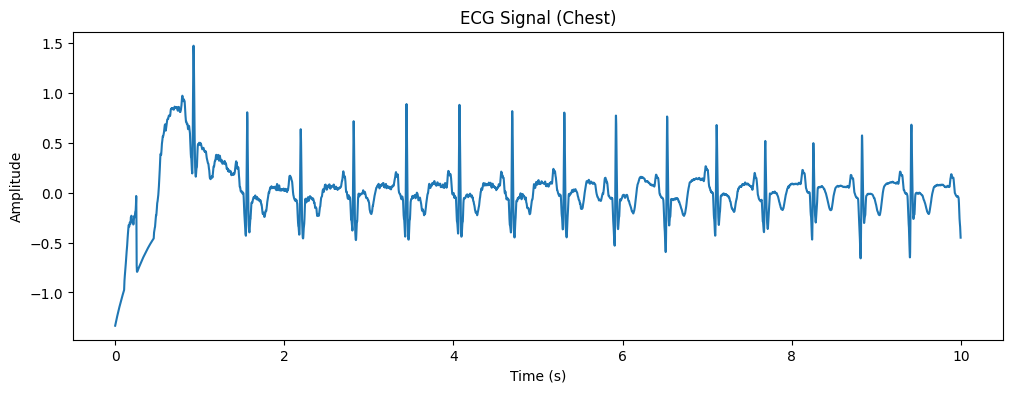

In [24]:
fs_ecg = 700  # Hz
t = np.arange(0, 10 * fs_ecg) / fs_ecg

plt.figure(figsize=(12,4))
plt.plot(t, ecg[:10 * fs_ecg])
plt.title("ECG Signal (Chest)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()


In [25]:
WINDOW_SEC = 60
STEP_SEC = 30

window_size = WINDOW_SEC * fs_ecg
step_size = STEP_SEC * fs_ecg


In [26]:
def create_windows(signal, labels, window_size, step_size):
    X, y = [], []
    for start in range(0, len(signal) - window_size, step_size):
        end = start + window_size
        window_label = np.bincount(labels[start:end]).argmax()
        if window_label == 0:
            continue
        X.append(signal[start:end])
        y.append(window_label)
    return np.array(X), np.array(y)


In [27]:
X_ecg, y = create_windows(ecg, labels, window_size, step_size)

print(X_ecg.shape)
print(np.unique(y, return_counts=True))


(108, 42000, 1)
(array([1, 2, 3, 4, 5, 6, 7]), array([39, 24, 12, 28,  2,  1,  2]))
